# ECG Classification â€“ Eksperimen Skema Preprocessing

Notebook ini melatih model klasifikasi ECG dengan **3 skema preprocessing** dan **2 task klasifikasi**, sehingga total terdapat **6 kombinasi eksperimen**.

| Skema | Input | Task |
|---|---|---|
| Skema 1 | Gambar clean (1 gambar/sampel) | 2-class & 4-class |
| Skema 2 | 12 short lead + 1 long lead | 2-class & 4-class |
| Skema 3 | 6 lead tungkai + 6 lead precordial + long lead | 2-class & 4-class |

Semua eksperimen di-tracking menggunakan **MLflow via DagsHub**.

## 1. Import & Konfigurasi

In [1]:
import torch
from utils.config import Config
from utils.modeling import (
    init_dagshub,
    CLASS_NAMES_2, CLASS_NAMES_4,
    SCHEME_NAMES,
)

c:\Users\abiyamf\Documents\Code Program\TelUxMMU-Research-CardiacData\.venv\Lib\site-packages\mlflow\utils\autologging_utils\versioning.py:6: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_filename


## GPU Check

In [2]:
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("GPU tidak tersedia, menggunakan CPU")

GPU: NVIDIA GeForce RTX 5070 Ti
Memory: 17.1 GB


In [3]:
# â”€â”€ Hyperparameter â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
NUM_EPOCHS    = 3
BATCH_SIZE    = 16
LEARNING_RATE = 1e-4
IMAGE_SIZE    = 224
VAL_SPLIT     = 0.15
TEST_SPLIT    = 0.15
OUTPUT_DIR    = "outputs/experiments"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


## 2. Inisialisasi DagsHub & MLflow

In [4]:
init_dagshub(
    repo_owner=Config.dagshub_config["repo_owner"],
    repo_name=Config.dagshub_config["repo_name"],
)

Accessing as abiyamf

Initialized MLflow to track repo "abiyamf/TelUxMMU-Research"

Repository abiyamf/TelUxMMU-Research initialized!

DagsHub initialized: https://dagshub.com/abiyamf/TelUxMMU-Research


In [5]:
from utils.modeling import (
    _get_image_files_scheme1,
    ECGDatasetScheme1,
    build_dataloaders,
    build_model,
    train_model,
    evaluate_and_log,
)

records_s1 = _get_image_files_scheme1(Config.data_root)

dataset_s1_4c = ECGDatasetScheme1(records_s1, task="4class", image_size=IMAGE_SIZE)
train_s1_4c, val_s1_4c, test_s1_4c = build_dataloaders(
    dataset_s1_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_s1_4c, history_s1_4c, run_output_dir_s1_4c, run_id_s1_4c = train_model(
    model_s1_4c, train_s1_4c, val_s1_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_4class",
    scheme="scheme1", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme1_4class] Epoch 1/3 | Train Loss: 0.5601 Acc: 0.8148 | Val Loss: 0.5325 Acc: 0.8429
[scheme1_4class] Epoch 2/3 | Train Loss: 0.1156 Acc: 0.9614 | Val Loss: 0.0879 Acc: 0.9714


2026/04/19 17:16:07 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_4class] Epoch 3/3 | Train Loss: 0.0466 Acc: 0.9938 | Val Loss: 0.0817 Acc: 0.9571


2026/04/19 17:16:12 WARNING mlflow.utils.environment: Encountered an unexpected error while inferring pip requirements (model URI: C:\Users\abiyamf\AppData\Local\Temp\tmpl1lclh9x\model\data, flavor: pytorch), fall back to return ['torch==2.11.0', 'cloudpickle==3.1.2']. Set logging level to DEBUG to see the full traceback.
2026/04/19 17:16:12 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_4class_20260419_171442\best_model.pth
Training history saved to: outputs/experiments\scheme1_4class_20260419_171442\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_4class_20260419_171442\confusion_matrix_val.png


In [6]:
result_s1_4c = evaluate_and_log(
    model_s1_4c, test_s1_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme1", task="4class",
    run_name="scheme1_4class",
    output_dir=run_output_dir_s1_4c,
    parent_run_id=run_id_s1_4c,
)


=== Test Results | scheme1 | 4class ===
Accuracy : 0.9643
Macro F1 : 0.9607
ROC-AUC  : 0.9963
              precision    recall  f1-score   support

      Normal       0.93      1.00      0.97        43
    Abnormal       0.97      0.94      0.96        35
          MI       1.00      1.00      1.00        36
  History MI       0.96      0.88      0.92        26

    accuracy                           0.96       140
   macro avg       0.97      0.96      0.96       140
weighted avg       0.96      0.96      0.96       140

Test confusion matrix saved to: outputs/experiments\scheme1_4class_20260419_171442\confusion_matrix_test.png


In [7]:
from utils.modeling import (
    _get_image_files_scheme1,
    ECGDatasetScheme1,
    build_dataloaders,
    build_model,
    train_model,
    evaluate_and_log,
)

records_s1 = _get_image_files_scheme1(Config.data_root)

dataset_s1_4c = ECGDatasetScheme1(records_s1, task="4class", image_size=IMAGE_SIZE)
train_s1_4c, val_s1_4c, test_s1_4c = build_dataloaders(
    dataset_s1_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_4c = build_model(num_classes=4, in_channels=3).to(DEVICE)

model_s1_4c, history_s1_4c, run_output_dir_s1_4c, run_id_s1_4c = train_model(
    model_s1_4c, train_s1_4c, val_s1_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_4class",
    output_dir=OUTPUT_DIR,
    scheme="scheme1", task="4class",
    class_names=CLASS_NAMES_4,
)

[scheme1_4class] Epoch 1/3 | Train Loss: 0.5836 Acc: 0.7731 | Val Loss: 0.6153 Acc: 0.8143
[scheme1_4class] Epoch 2/3 | Train Loss: 0.1164 Acc: 0.9707 | Val Loss: 0.1249 Acc: 0.9571


2026/04/19 17:19:18 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_4class] Epoch 3/3 | Train Loss: 0.0359 Acc: 0.9938 | Val Loss: 0.0815 Acc: 0.9714


2026/04/19 17:19:23 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:19:23 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_4class_20260419_171732\best_model.pth
Training history saved to: outputs/experiments\scheme1_4class_20260419_171732\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_4class_20260419_171732\confusion_matrix_val.png


In [8]:
dataset_s1_2c = ECGDatasetScheme1(records_s1, task="2class", image_size=IMAGE_SIZE)
train_s1_2c, val_s1_2c, test_s1_2c = build_dataloaders(
    dataset_s1_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_s1_2c, history_s1_2c, run_output_dir_s1_2c, run_id_s1_2c = train_model(
    model_s1_2c, train_s1_2c, val_s1_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_2class",
    scheme="scheme1", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme1_2class] Epoch 1/3 | Train Loss: 0.2248 Acc: 0.8966 | Val Loss: 0.2517 Acc: 0.9143
[scheme1_2class] Epoch 2/3 | Train Loss: 0.0669 Acc: 0.9799 | Val Loss: 0.0669 Acc: 0.9643


2026/04/19 17:22:10 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_2class] Epoch 3/3 | Train Loss: 0.0538 Acc: 0.9815 | Val Loss: 0.1219 Acc: 0.9643


2026/04/19 17:22:14 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:22:14 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_2class_20260419_172027\best_model.pth
Training history saved to: outputs/experiments\scheme1_2class_20260419_172027\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_2class_20260419_172027\confusion_matrix_val.png


In [9]:
result_s1_2c = evaluate_and_log(
    model_s1_2c, test_s1_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme1", task="2class",
    run_name="scheme1_2class",
    output_dir=run_output_dir_s1_2c,
    parent_run_id=run_id_s1_2c,
)


=== Test Results | scheme1 | 2class ===
Accuracy : 0.9714
Macro F1 : 0.9660
ROC-AUC  : 0.9993
              precision    recall  f1-score   support

       Sehat       0.98      0.93      0.95        43
       Sakit       0.97      0.99      0.98        97

    accuracy                           0.97       140
   macro avg       0.97      0.96      0.97       140
weighted avg       0.97      0.97      0.97       140

Test confusion matrix saved to: outputs/experiments\scheme1_2class_20260419_172027\confusion_matrix_test.png


In [10]:
dataset_s1_2c = ECGDatasetScheme1(records_s1, task="2class", image_size=IMAGE_SIZE)
train_s1_2c, val_s1_2c, test_s1_2c = build_dataloaders(
    dataset_s1_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s1_2c = build_model(num_classes=2, in_channels=3).to(DEVICE)

model_s1_2c, history_s1_2c, run_output_dir_s1_2c, run_id_s1_2c = train_model(
    model_s1_2c, train_s1_2c, val_s1_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme1_2class",
    output_dir=OUTPUT_DIR,
    scheme="scheme1", task="2class",
    class_names=CLASS_NAMES_2,
)

[scheme1_2class] Epoch 1/3 | Train Loss: 0.2382 Acc: 0.8981 | Val Loss: 0.2912 Acc: 0.8214
[scheme1_2class] Epoch 2/3 | Train Loss: 0.0546 Acc: 0.9846 | Val Loss: 0.0732 Acc: 0.9643


2026/04/19 17:25:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme1_2class] Epoch 3/3 | Train Loss: 0.0189 Acc: 0.9938 | Val Loss: 0.1556 Acc: 0.9643


2026/04/19 17:25:25 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:25:25 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme1_2class_20260419_172332\best_model.pth
Training history saved to: outputs/experiments\scheme1_2class_20260419_172332\training_history.png
Confusion matrix saved to: outputs/experiments\scheme1_2class_20260419_172332\confusion_matrix_val.png


In [11]:
result_s1_2c = evaluate_and_log(
    model_s1_2c, test_s1_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme1", task="2class",
    run_name="scheme1_2class",
    output_dir=run_output_dir_s1_2c,
    parent_run_id=run_id_s1_2c,
)


=== Test Results | scheme1 | 2class ===
Accuracy : 0.9857
Macro F1 : 0.9834
ROC-AUC  : 0.9986
              precision    recall  f1-score   support

       Sehat       0.96      1.00      0.98        43
       Sakit       1.00      0.98      0.99        97

    accuracy                           0.99       140
   macro avg       0.98      0.99      0.98       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme1_2class_20260419_172332\confusion_matrix_test.png


In [12]:
from utils.modeling import _get_image_files_scheme2, ECGDatasetScheme2

records_s2 = _get_image_files_scheme2(Config.data_root)

dataset_s2_4c = ECGDatasetScheme2(records_s2, task="4class", image_size=IMAGE_SIZE)
train_s2_4c, val_s2_4c, test_s2_4c = build_dataloaders(
    dataset_s2_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# 13 leads x 3 channels = 39 input channels
model_s2_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s2_4c, history_s2_4c, run_output_dir_s2_4c, run_id_s2_4c = train_model(
    model_s2_4c, train_s2_4c, val_s2_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_4class",
    scheme="scheme2", task="4class",
    model_name="ResNet-18", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme2_4class] Epoch 1/3 | Train Loss: 0.5733 Acc: 0.7963 | Val Loss: 1.0625 Acc: 0.5214
[scheme2_4class] Epoch 2/3 | Train Loss: 0.1139 Acc: 0.9722 | Val Loss: 0.3447 Acc: 0.8571


2026/04/19 17:29:32 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_4class] Epoch 3/3 | Train Loss: 0.0363 Acc: 0.9954 | Val Loss: 0.2495 Acc: 0.9286


2026/04/19 17:29:37 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:29:37 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_4class_20260419_172656\best_model.pth
Training history saved to: outputs/experiments\scheme2_4class_20260419_172656\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_4class_20260419_172656\confusion_matrix_val.png


In [13]:
result_s2_4c = evaluate_and_log(
    model_s2_4c, test_s2_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme2", task="4class",
    run_name="scheme2_4class",
    output_dir=run_output_dir_s2_4c,
    parent_run_id=run_id_s2_4c,
)


=== Test Results | scheme2 | 4class ===
Accuracy : 0.9643
Macro F1 : 0.9643
ROC-AUC  : 0.9893
              precision    recall  f1-score   support

      Normal       1.00      0.93      0.96        43
    Abnormal       0.90      1.00      0.95        35
          MI       1.00      0.97      0.99        36
  History MI       0.96      0.96      0.96        26

    accuracy                           0.96       140
   macro avg       0.96      0.97      0.96       140
weighted avg       0.97      0.96      0.96       140

Test confusion matrix saved to: outputs/experiments\scheme2_4class_20260419_172656\confusion_matrix_test.png


In [14]:
from utils.modeling import _get_image_files_scheme2, ECGDatasetScheme2

records_s2 = _get_image_files_scheme2(Config.data_root)

dataset_s2_4c = ECGDatasetScheme2(records_s2, task="4class", image_size=IMAGE_SIZE)
train_s2_4c, val_s2_4c, test_s2_4c = build_dataloaders(
    dataset_s2_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s2_4c = build_model(num_classes=4, in_channels=39).to(DEVICE)

model_s2_4c, history_s2_4c, run_output_dir_s2_4c, run_id_s2_4c = train_model(
    model_s2_4c, train_s2_4c, val_s2_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_4class",
    output_dir=OUTPUT_DIR,
    scheme="scheme2", task="4class",
    class_names=CLASS_NAMES_4,
)

[scheme2_4class] Epoch 1/3 | Train Loss: 0.6212 Acc: 0.7731 | Val Loss: 0.7215 Acc: 0.6929
[scheme2_4class] Epoch 2/3 | Train Loss: 0.1206 Acc: 0.9676 | Val Loss: 0.5070 Acc: 0.8071


2026/04/19 17:33:51 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_4class] Epoch 3/3 | Train Loss: 0.0377 Acc: 0.9907 | Val Loss: 0.3553 Acc: 0.8929


2026/04/19 17:33:56 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:33:56 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_4class_20260419_173114\best_model.pth
Training history saved to: outputs/experiments\scheme2_4class_20260419_173114\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_4class_20260419_173114\confusion_matrix_val.png


In [15]:
dataset_s2_2c = ECGDatasetScheme2(records_s2, task="2class", image_size=IMAGE_SIZE)
train_s2_2c, val_s2_2c, test_s2_2c = build_dataloaders(
    dataset_s2_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s2_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s2_2c, history_s2_2c, run_output_dir_s2_2c, run_id_s2_2c = train_model(
    model_s2_2c, train_s2_2c, val_s2_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_2class",
    scheme="scheme2", task="2class",
    model_name="ResNet-18", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme2_2class] Epoch 1/3 | Train Loss: 0.2183 Acc: 0.9074 | Val Loss: 0.8157 Acc: 0.7143
[scheme2_2class] Epoch 2/3 | Train Loss: 0.0614 Acc: 0.9784 | Val Loss: 0.2997 Acc: 0.8786


2026/04/19 17:37:47 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_2class] Epoch 3/3 | Train Loss: 0.0964 Acc: 0.9660 | Val Loss: 0.1747 Acc: 0.9571


2026/04/19 17:37:52 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:37:52 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_2class_20260419_173511\best_model.pth
Training history saved to: outputs/experiments\scheme2_2class_20260419_173511\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_2class_20260419_173511\confusion_matrix_val.png


In [16]:
result_s2_2c = evaluate_and_log(
    model_s2_2c, test_s2_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme2", task="2class",
    run_name="scheme2_2class",
    output_dir=run_output_dir_s2_2c,
    parent_run_id=run_id_s2_2c,
)


=== Test Results | scheme2 | 2class ===
Accuracy : 0.9643
Macro F1 : 0.9572
ROC-AUC  : 0.9916
              precision    recall  f1-score   support

       Sehat       0.97      0.91      0.94        43
       Sakit       0.96      0.99      0.97        97

    accuracy                           0.96       140
   macro avg       0.97      0.95      0.96       140
weighted avg       0.96      0.96      0.96       140

Test confusion matrix saved to: outputs/experiments\scheme2_2class_20260419_173511\confusion_matrix_test.png


In [17]:
dataset_s2_2c = ECGDatasetScheme2(records_s2, task="2class", image_size=IMAGE_SIZE)
train_s2_2c, val_s2_2c, test_s2_2c = build_dataloaders(
    dataset_s2_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s2_2c = build_model(num_classes=2, in_channels=39).to(DEVICE)

model_s2_2c, history_s2_2c, run_output_dir_s2_2c, run_id_s2_2c = train_model(
    model_s2_2c, train_s2_2c, val_s2_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme2_2class",
    output_dir=OUTPUT_DIR,
    scheme="scheme2", task="2class",
    class_names=CLASS_NAMES_2,
)

[scheme2_2class] Epoch 1/3 | Train Loss: 0.2460 Acc: 0.8843 | Val Loss: 0.8331 Acc: 0.6929
[scheme2_2class] Epoch 2/3 | Train Loss: 0.0895 Acc: 0.9722 | Val Loss: 0.9914 Acc: 0.6929


2026/04/19 17:42:03 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme2_2class] Epoch 3/3 | Train Loss: 0.0480 Acc: 0.9846 | Val Loss: 0.4305 Acc: 0.8429


2026/04/19 17:42:08 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:42:08 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme2_2class_20260419_173927\best_model.pth
Training history saved to: outputs/experiments\scheme2_2class_20260419_173927\training_history.png
Confusion matrix saved to: outputs/experiments\scheme2_2class_20260419_173927\confusion_matrix_val.png


In [18]:
result_s2_2c = evaluate_and_log(
    model_s2_2c, test_s2_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme2", task="2class",
    run_name="scheme2_2class",
    output_dir=run_output_dir_s2_2c,
    parent_run_id=run_id_s2_2c,
)


=== Test Results | scheme2 | 2class ===
Accuracy : 0.8500
Macro F1 : 0.7896
ROC-AUC  : 0.9940
              precision    recall  f1-score   support

       Sehat       1.00      0.51      0.68        43
       Sakit       0.82      1.00      0.90        97

    accuracy                           0.85       140
   macro avg       0.91      0.76      0.79       140
weighted avg       0.88      0.85      0.83       140

Test confusion matrix saved to: outputs/experiments\scheme2_2class_20260419_173927\confusion_matrix_test.png


In [19]:
from utils.modeling import (
    _get_image_files_scheme3,
    ECGDatasetScheme3,
    build_model_multibranch,
    MultiBranchResNet18,
)

records_s3 = _get_image_files_scheme3(Config.data_root)

dataset_s3_4c = ECGDatasetScheme3(records_s3, task="4class", image_size=IMAGE_SIZE)
train_s3_4c, val_s3_4c, test_s3_4c = build_dataloaders(
    dataset_s3_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

# Multi-branch: limb (18ch) + precordial (18ch) + long lead (3ch)
model_s3_4c = build_model_multibranch(num_classes=4).to(DEVICE)

model_s3_4c, history_s3_4c, run_output_dir_s3_4c, run_id_s3_4c = train_model(
    model_s3_4c, train_s3_4c, val_s3_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_4class",
    scheme="scheme3", task="4class",
    model_name="ResNet-18 MultiBranch", class_names=CLASS_NAMES_4,
    output_dir=OUTPUT_DIR
)

[scheme3_4class] Epoch 1/3 | Train Loss: 0.4606 Acc: 0.8349 | Val Loss: 0.3193 Acc: 0.9000
[scheme3_4class] Epoch 2/3 | Train Loss: 0.0625 Acc: 0.9846 | Val Loss: 0.1172 Acc: 0.9857


2026/04/19 17:46:23 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_4class] Epoch 3/3 | Train Loss: 0.0265 Acc: 0.9907 | Val Loss: 0.0898 Acc: 0.9714


2026/04/19 17:46:29 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:46:29 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_4class_20260419_174347\best_model.pth
Training history saved to: outputs/experiments\scheme3_4class_20260419_174347\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_4class_20260419_174347\confusion_matrix_val.png


In [20]:
result_s3_4c = evaluate_and_log(
    model_s3_4c, test_s3_4c, DEVICE,
    class_names=CLASS_NAMES_4,
    scheme="scheme3", task="4class",
    run_name="scheme3_4class",
    output_dir=run_output_dir_s3_4c,
    parent_run_id=run_id_s3_4c,
)


=== Test Results | scheme3 | 4class ===
Accuracy : 0.9714
Macro F1 : 0.9685
ROC-AUC  : 0.9930
              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99        43
    Abnormal       0.92      0.97      0.94        35
          MI       1.00      1.00      1.00        36
  History MI       0.96      0.92      0.94        26

    accuracy                           0.97       140
   macro avg       0.97      0.97      0.97       140
weighted avg       0.97      0.97      0.97       140

Test confusion matrix saved to: outputs/experiments\scheme3_4class_20260419_174347\confusion_matrix_test.png


In [21]:
from utils.modeling import (
    _get_image_files_scheme3,
    ECGDatasetScheme3,
    build_model_multibranch,
)

records_s3 = _get_image_files_scheme3(Config.data_root)

dataset_s3_4c = ECGDatasetScheme3(records_s3, task="4class", image_size=IMAGE_SIZE)
train_s3_4c, val_s3_4c, test_s3_4c = build_dataloaders(
    dataset_s3_4c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_4c = build_model_multibranch(num_classes=4).to(DEVICE)

model_s3_4c, history_s3_4c, run_output_dir_s3_4c, run_id_s3_4c = train_model(
    model_s3_4c, train_s3_4c, val_s3_4c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_4class",
    output_dir=OUTPUT_DIR,
    scheme="scheme3", task="4class",
    class_names=CLASS_NAMES_4,
)

[scheme3_4class] Epoch 1/3 | Train Loss: 0.4710 Acc: 0.8272 | Val Loss: 0.5957 Acc: 0.7643
[scheme3_4class] Epoch 2/3 | Train Loss: 0.0443 Acc: 0.9923 | Val Loss: 0.0945 Acc: 0.9714


2026/04/19 17:51:12 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_4class] Epoch 3/3 | Train Loss: 0.0111 Acc: 1.0000 | Val Loss: 0.0651 Acc: 0.9857


2026/04/19 17:51:19 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:51:19 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_4class_20260419_174843\best_model.pth
Training history saved to: outputs/experiments\scheme3_4class_20260419_174843\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_4class_20260419_174843\confusion_matrix_val.png


In [22]:
dataset_s3_2c = ECGDatasetScheme3(records_s3, task="2class", image_size=IMAGE_SIZE)
train_s3_2c, val_s3_2c, test_s3_2c = build_dataloaders(
    dataset_s3_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_2c = build_model_multibranch(num_classes=2).to(DEVICE)

model_s3_2c, history_s3_2c, run_output_dir_s3_2c, run_id_s3_2c = train_model(
    model_s3_2c, train_s3_2c, val_s3_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_2class",
    scheme="scheme3", task="2class",
    model_name="ResNet-18 MultiBranch", class_names=CLASS_NAMES_2,
    output_dir=OUTPUT_DIR
)

[scheme3_2class] Epoch 1/3 | Train Loss: 0.2160 Acc: 0.9105 | Val Loss: 0.1988 Acc: 0.9214
[scheme3_2class] Epoch 2/3 | Train Loss: 0.0361 Acc: 0.9892 | Val Loss: 0.0495 Acc: 0.9786


2026/04/19 17:55:25 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_2class] Epoch 3/3 | Train Loss: 0.0154 Acc: 0.9954 | Val Loss: 0.1283 Acc: 0.9643


2026/04/19 17:55:32 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 17:55:32 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_2class_20260419_175306\best_model.pth
Training history saved to: outputs/experiments\scheme3_2class_20260419_175306\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_2class_20260419_175306\confusion_matrix_val.png


In [23]:
result_s3_2c = evaluate_and_log(
    model_s3_2c, test_s3_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme3", task="2class",
    run_name="scheme3_2class",
    output_dir=run_output_dir_s3_2c,
    parent_run_id=run_id_s3_2c,
)


=== Test Results | scheme3 | 2class ===
Accuracy : 0.9857
Macro F1 : 0.9832
ROC-AUC  : 0.9998
              precision    recall  f1-score   support

       Sehat       0.98      0.98      0.98        43
       Sakit       0.99      0.99      0.99        97

    accuracy                           0.99       140
   macro avg       0.98      0.98      0.98       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme3_2class_20260419_175306\confusion_matrix_test.png


In [24]:
dataset_s3_2c = ECGDatasetScheme3(records_s3, task="2class", image_size=IMAGE_SIZE)
train_s3_2c, val_s3_2c, test_s3_2c = build_dataloaders(
    dataset_s3_2c, seed=Config.seed, batch_size=BATCH_SIZE,
    val_split=VAL_SPLIT, test_split=TEST_SPLIT
)

model_s3_2c = build_model_multibranch(num_classes=2).to(DEVICE)

model_s3_2c, history_s3_2c, run_output_dir_s3_2c, run_id_s3_2c = train_model(
    model_s3_2c, train_s3_2c, val_s3_2c,
    num_epochs=NUM_EPOCHS, learning_rate=LEARNING_RATE,
    device=DEVICE, run_name="scheme3_2class",
    output_dir=OUTPUT_DIR,
    scheme="scheme3", task="2class",
    class_names=CLASS_NAMES_2,
)

[scheme3_2class] Epoch 1/3 | Train Loss: 0.2709 Acc: 0.8812 | Val Loss: 0.3313 Acc: 0.8286
[scheme3_2class] Epoch 2/3 | Train Loss: 0.0401 Acc: 0.9892 | Val Loss: 0.1408 Acc: 0.9286


2026/04/19 18:00:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.11.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torch==2.11.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


[scheme3_2class] Epoch 3/3 | Train Loss: 0.0160 Acc: 0.9969 | Val Loss: 0.0912 Acc: 0.9857


2026/04/19 18:00:31 WARNING mlflow.utils.requirements_utils: Found torchvision version (0.26.0+cu130) contains a local version label (+cu130). MLflow logged a pip requirement for this package as 'torchvision==0.26.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/04/19 18:00:31 WARNING mlflow.utils.environment: Failed to resolve installed pip version. ``pip`` will be added to conda.yaml environment spec without a version specifier.


Model saved locally to: outputs/experiments\scheme3_2class_20260419_175752\best_model.pth
Training history saved to: outputs/experiments\scheme3_2class_20260419_175752\training_history.png
Confusion matrix saved to: outputs/experiments\scheme3_2class_20260419_175752\confusion_matrix_val.png


In [25]:
result_s3_2c = evaluate_and_log(
    model_s3_2c, test_s3_2c, DEVICE,
    class_names=CLASS_NAMES_2,
    scheme="scheme3", task="2class",
    run_name="scheme3_2class",
    output_dir=run_output_dir_s3_2c,
    parent_run_id=run_id_s3_2c,
)


=== Test Results | scheme3 | 2class ===
Accuracy : 0.9929
Macro F1 : 0.9917
ROC-AUC  : 0.9986
              precision    recall  f1-score   support

       Sehat       0.98      1.00      0.99        43
       Sakit       1.00      0.99      0.99        97

    accuracy                           0.99       140
   macro avg       0.99      0.99      0.99       140
weighted avg       0.99      0.99      0.99       140

Test confusion matrix saved to: outputs/experiments\scheme3_2class_20260419_175752\confusion_matrix_test.png


=== Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch) ===
                 Scheme    Task  Accuracy  Macro F1  ROC-AUC
       Scheme 2 (Stack) 4-Class    0.9643    0.9643   0.9893
       Scheme 2 (Stack) 2-Class    0.8500    0.7896   0.9940
Scheme 3 (Multi-Branch) 4-Class    0.9714    0.9685   0.9930
Scheme 3 (Multi-Branch) 2-Class    0.9929    0.9917   0.9986


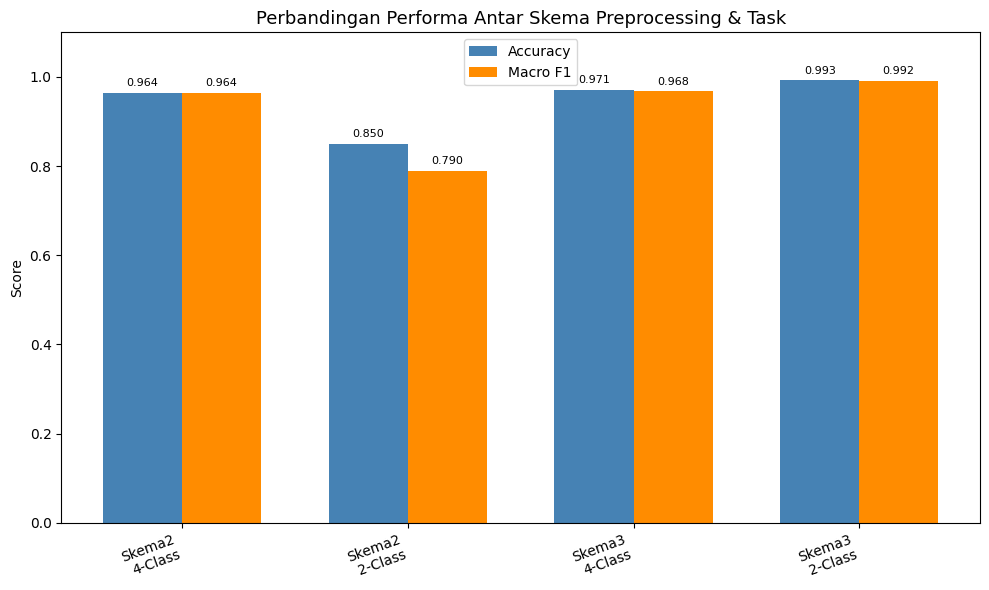

In [26]:
# Perbandingan Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch)
import pandas as pd

comparison_data = {
    "Scheme":   ["Scheme 2 (Stack)", "Scheme 2 (Stack)",
                 "Scheme 3 (Multi-Branch)", "Scheme 3 (Multi-Branch)"],
    "Task":     ["4-Class", "2-Class", "4-Class", "2-Class"],
    "Accuracy": [result_s2_4c["accuracy"], result_s2_2c["accuracy"],
                 result_s3_4c["accuracy"], result_s3_2c["accuracy"]],
    "Macro F1": [result_s2_4c["f1"],       result_s2_2c["f1"],
                 result_s3_4c["f1"],        result_s3_2c["f1"]],
    "ROC-AUC":  [result_s2_4c["roc_auc"],  result_s2_2c["roc_auc"],
                 result_s3_4c["roc_auc"],   result_s3_2c["roc_auc"]],
}

df_compare = pd.DataFrame(comparison_data)
print("=== Scheme 2 (Channel-Stack) vs Scheme 3 (Multi-Branch) ===")
print(df_compare.to_string(index=False, float_format="{:.4f}".format))

from utils.modeling import plot_scheme_comparison
plot_scheme_comparison({
    "Skema2\n4-Class": result_s2_4c,
    "Skema2\n2-Class": result_s2_2c,
    "Skema3\n4-Class": result_s3_4c,
    "Skema3\n2-Class": result_s3_2c,
})

## 6. Visualisasi Perbandingan Hasil

Bagian ini membandingkan performa semua skema dan task secara visual.

### 6.1 Training History â€“ Task 4-Class

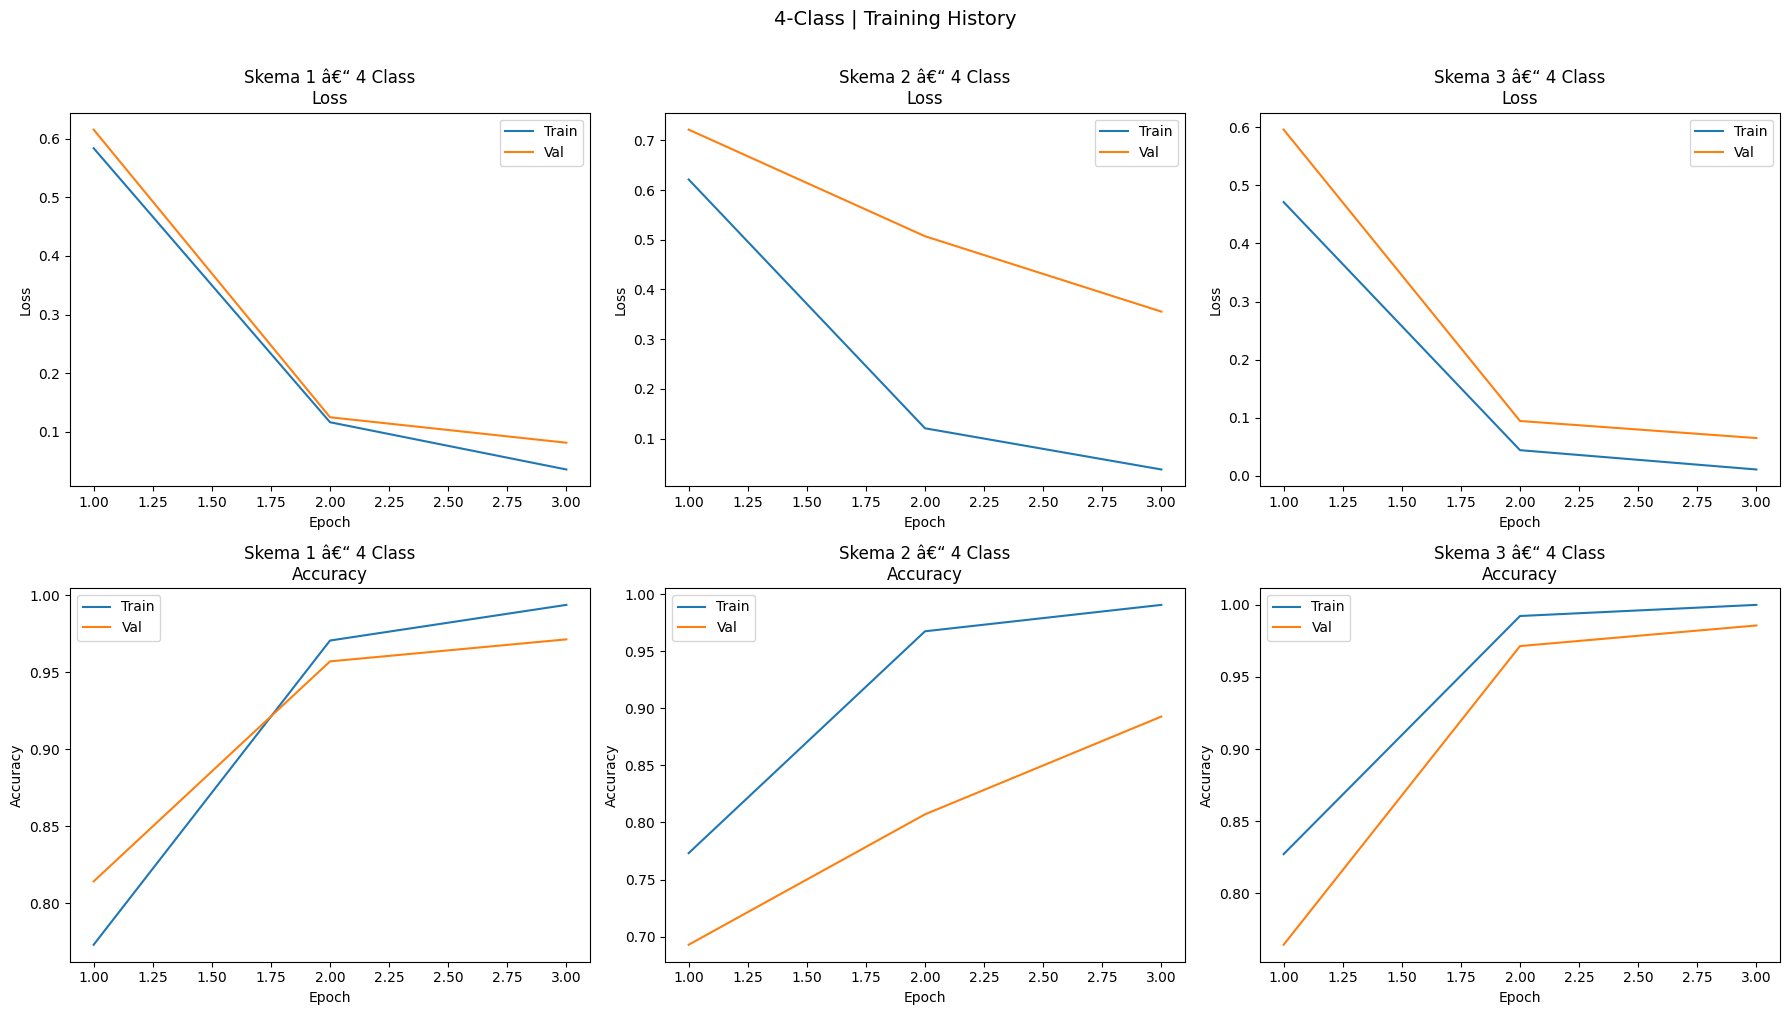

In [27]:
from utils.modeling import plot_training_history

plot_training_history(
    histories={
        "Skema 1 â€“ 4 Class": history_s1_4c,
        "Skema 2 â€“ 4 Class": history_s2_4c,
        "Skema 3 â€“ 4 Class": history_s3_4c,
    },
    title_prefix="4-Class | "
)

### 6.2 Training History â€“ Task 2-Class

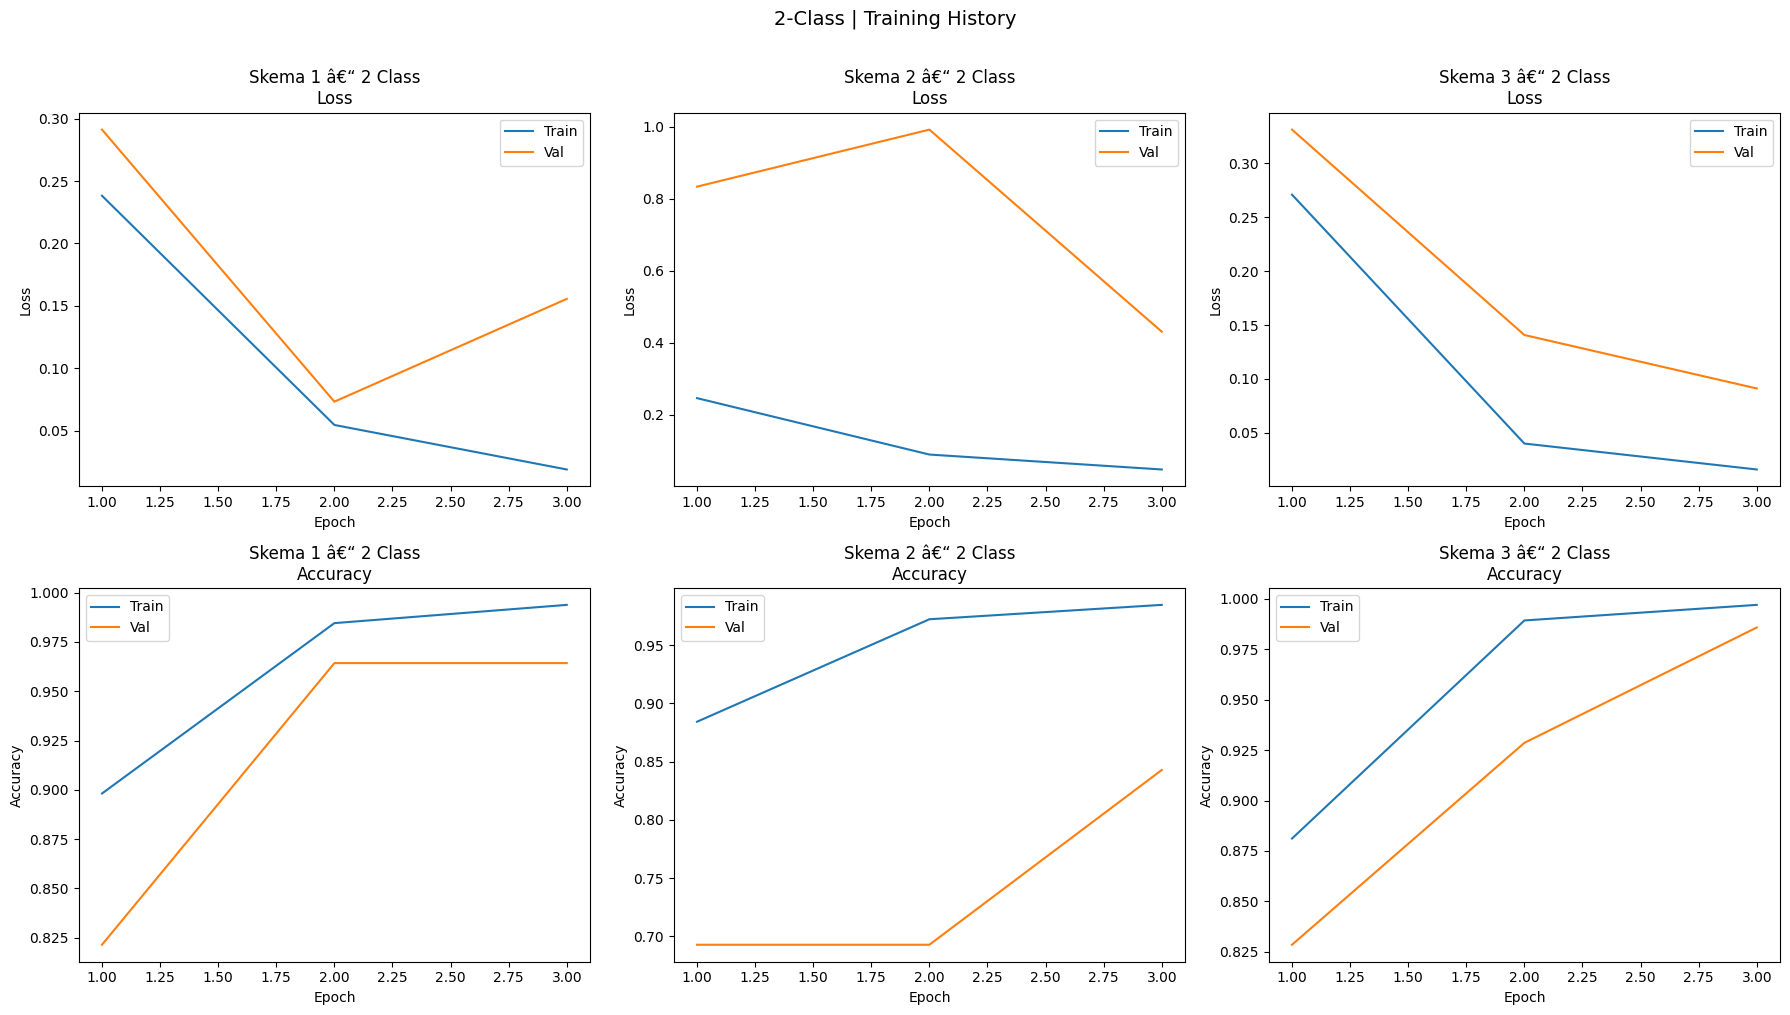

In [28]:
plot_training_history(
    histories={
        "Skema 1 â€“ 2 Class": history_s1_2c,
        "Skema 2 â€“ 2 Class": history_s2_2c,
        "Skema 3 â€“ 2 Class": history_s3_2c,
    },
    title_prefix="2-Class | "
)

### 6.3 Confusion Matrix â€“ Task 4-Class

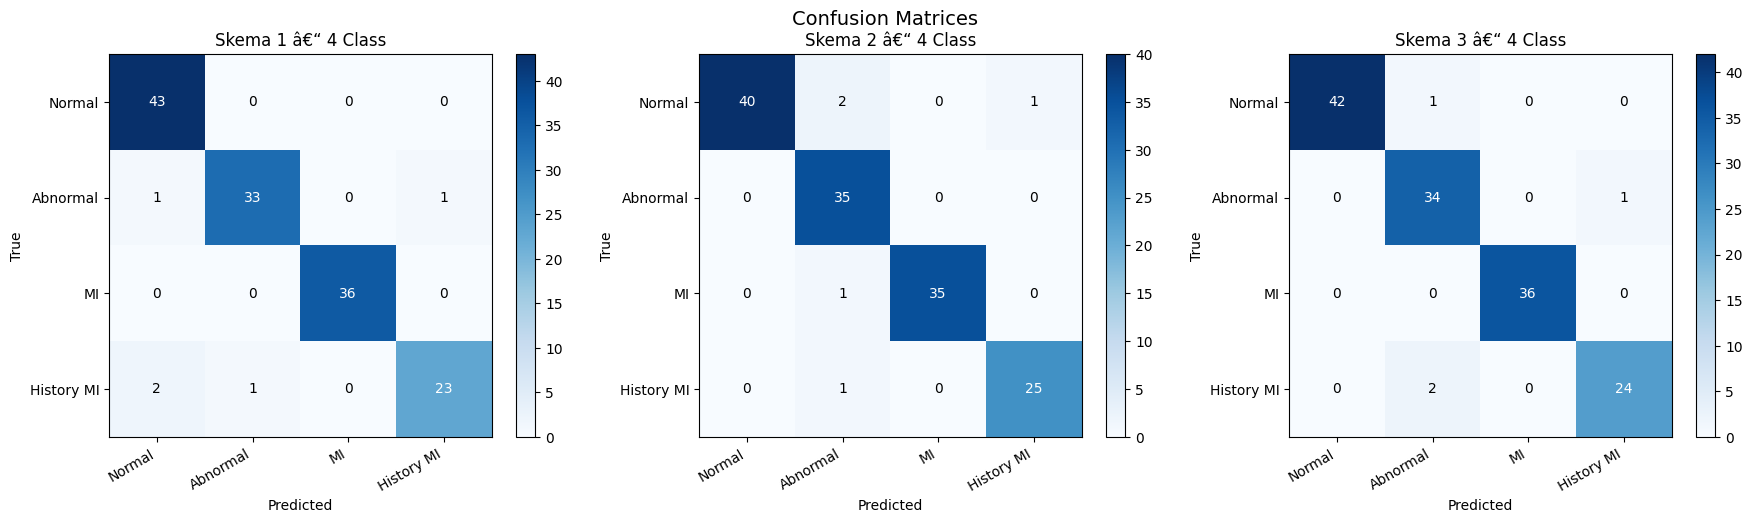

In [29]:
from utils.modeling import plot_confusion_matrices

plot_confusion_matrices(
    results={
        "Skema 1 â€“ 4 Class": result_s1_4c,
        "Skema 2 â€“ 4 Class": result_s2_4c,
        "Skema 3 â€“ 4 Class": result_s3_4c,
    },
    class_names=CLASS_NAMES_4
)

### 6.4 Confusion Matrix â€“ Task 2-Class

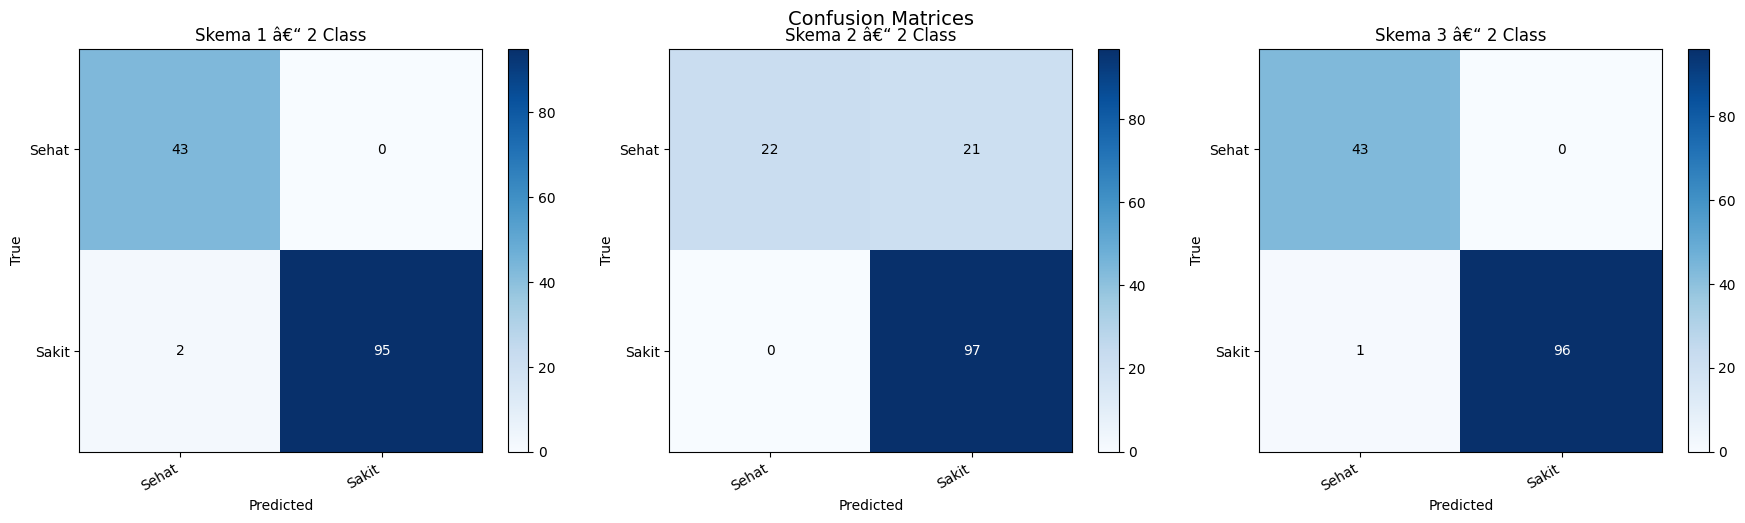

In [30]:
plot_confusion_matrices(
    results={
        "Skema 1 â€“ 2 Class": result_s1_2c,
        "Skema 2 â€“ 2 Class": result_s2_2c,
        "Skema 3 â€“ 2 Class": result_s3_2c,
    },
    class_names=CLASS_NAMES_2
)

### 6.5 Perbandingan Akhir â€“ Accuracy & Macro F1 Semua Skema

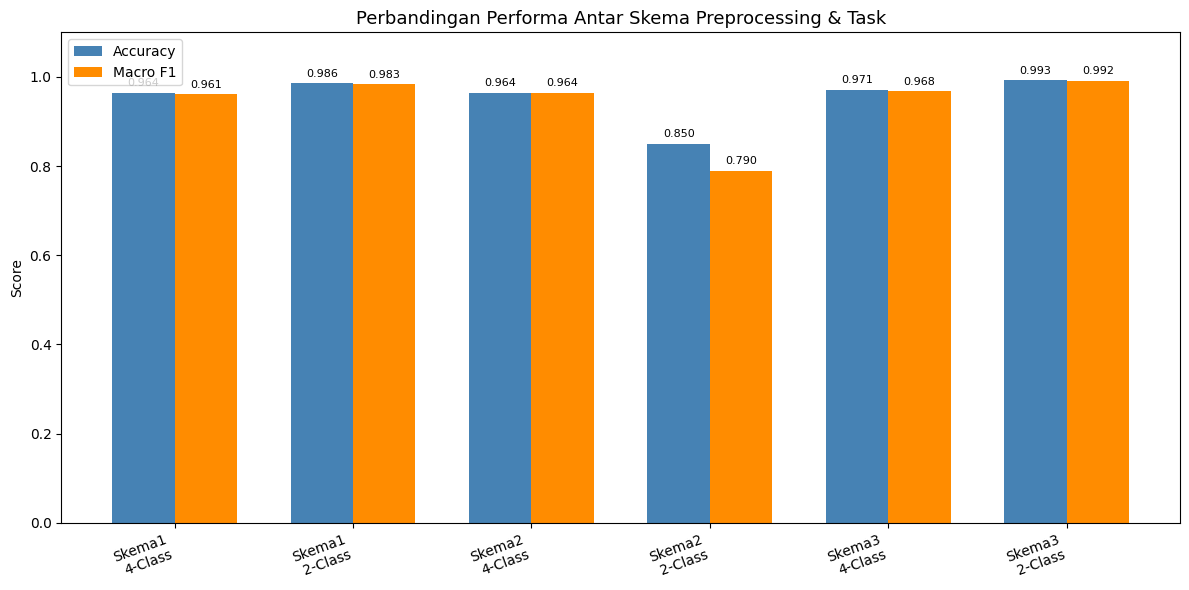

In [31]:
from utils.modeling import plot_scheme_comparison

all_results = {
    "Skema1\n4-Class": result_s1_4c,
    "Skema1\n2-Class": result_s1_2c,
    "Skema2\n4-Class": result_s2_4c,
    "Skema2\n2-Class": result_s2_2c,
    "Skema3\n4-Class": result_s3_4c,
    "Skema3\n2-Class": result_s3_2c,
}

plot_scheme_comparison(all_results)

### 6.6 Sample Predictions â€“ Skema Terbaik

Visualisasi prediksi model pada sampel acak dari dataset test. Ganti variabel `best_model` dan `best_dataset` sesuai skema dengan performa terbaik dari grafik di atas.

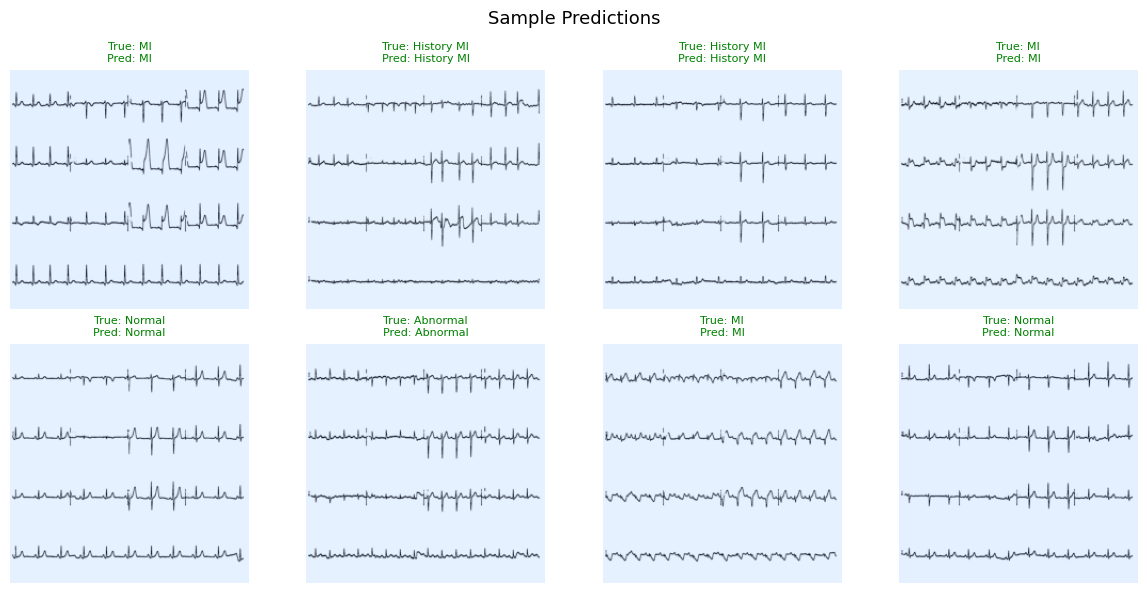

In [32]:
from utils.modeling import plot_sample_predictions

# Ganti model dan dataset sesuai hasil terbaik yang diperoleh
best_model   = model_s1_4c
best_dataset = dataset_s1_4c
best_classes = CLASS_NAMES_4

plot_sample_predictions(
    model=best_model,
    dataset=best_dataset,
    class_names=best_classes,
    device=DEVICE,
    num_samples=8
)